In [1]:
import os
import itertools
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PROJECT_DIR = "/content/drive/MyDrive/computervisionproject"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "processed_dataset"
)

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "best_model.keras"
)

REPORT_DIR = os.path.join(
    PROJECT_DIR,
    "reports"
)

os.makedirs(REPORT_DIR, exist_ok=True)

In [4]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(

    os.path.join(DATASET_DIR,"test"),

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)

Found 1518 files belonging to 3 classes.


In [6]:
model = tf.keras.models.load_model(MODEL_PATH)

print("Model Loaded Successfully")

Model Loaded Successfully


In [7]:
predictions = model.predict(test_ds)

y_pred = np.argmax(predictions, axis=1)

y_true = np.concatenate(
    [y.numpy() for x, y in test_ds]
)

class_names = test_ds.class_names

print(class_names)

48/48 ━━━━━━━━━━━━━━━━━━━━ 206s 4s/step
['COVID', 'Normal', 'Viral Pneumonia']


In [8]:
report = classification_report(

    y_true,

    y_pred,

    target_names=class_names

)

print(report)

                 precision    recall  f1-score   support

          COVID       0.87      0.95      0.91       363
         Normal       0.98      0.94      0.96      1020
Viral Pneumonia       0.94      0.96      0.95       135

       accuracy                           0.95      1518
      macro avg       0.93      0.95      0.94      1518
   weighted avg       0.95      0.95      0.95      1518



In [9]:
with open(
    os.path.join(
        REPORT_DIR,
        "classification_report.txt"
    ),
    "w"
) as f:

    f.write(report)

print("Classification Report Saved")

Classification Report Saved


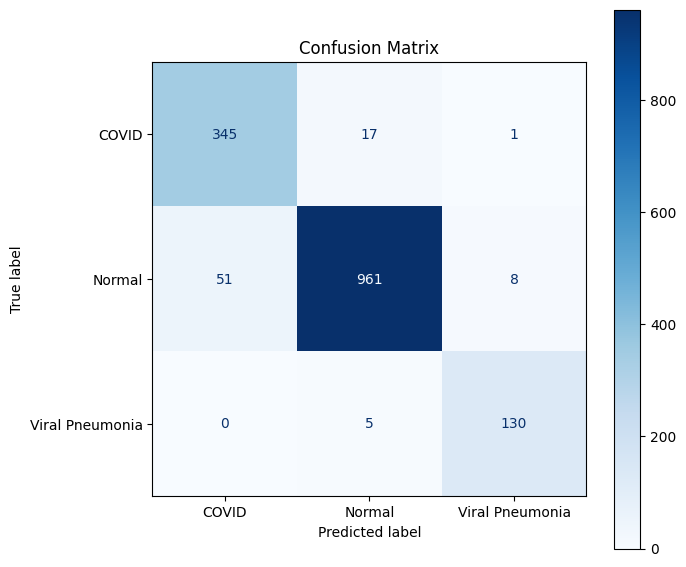

In [10]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7,7))

disp.plot(ax=ax,cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    os.path.join(
        REPORT_DIR,
        "confusion_matrix.png"
    ),
    dpi=300
)

plt.show()

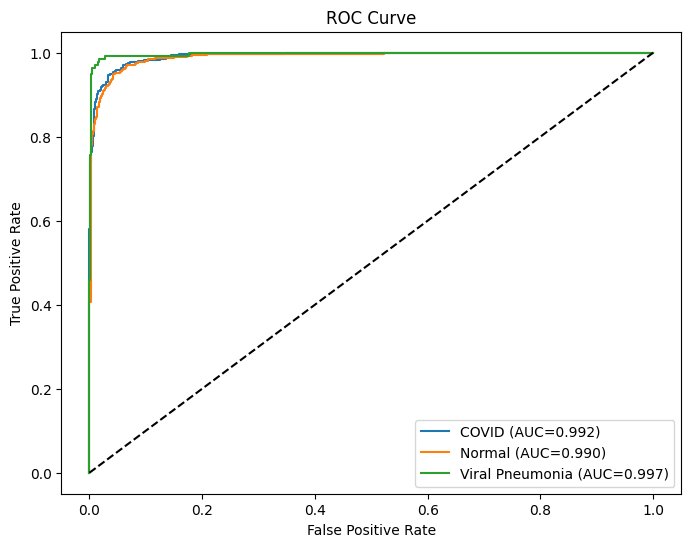

In [11]:
y_true_bin = label_binarize(
    y_true,
    classes=[0,1,2]
)

plt.figure(figsize=(8,6))

for i in range(3):

    fpr,tpr,_ = roc_curve(
        y_true_bin[:,i],
        predictions[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig(
    os.path.join(
        REPORT_DIR,
        "roc_curve.png"
    ),
    dpi=300
)

plt.show()

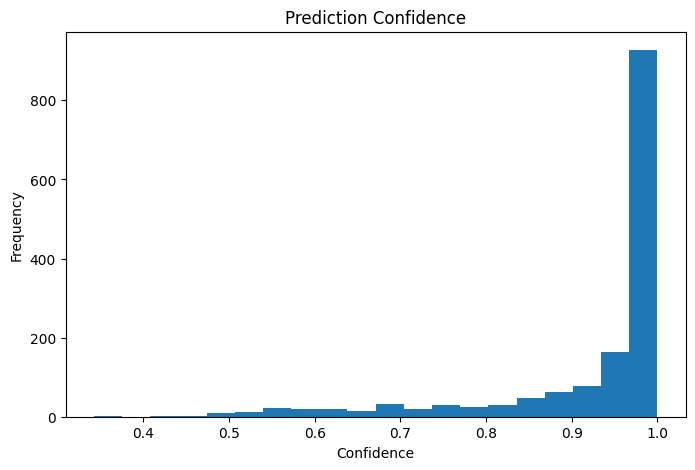

In [12]:
confidence = np.max(
    predictions,
    axis=1
)

plt.figure(figsize=(8,5))

plt.hist(
    confidence,
    bins=20
)

plt.title("Prediction Confidence")

plt.xlabel("Confidence")

plt.ylabel("Frequency")

plt.savefig(
    os.path.join(
        REPORT_DIR,
        "confidence_histogram.png"
    ),
    dpi=300
)

plt.show()

In [13]:
misclassified = np.where(
    y_true != y_pred
)[0]

print("Total Misclassified:", len(misclassified))

Total Misclassified: 82


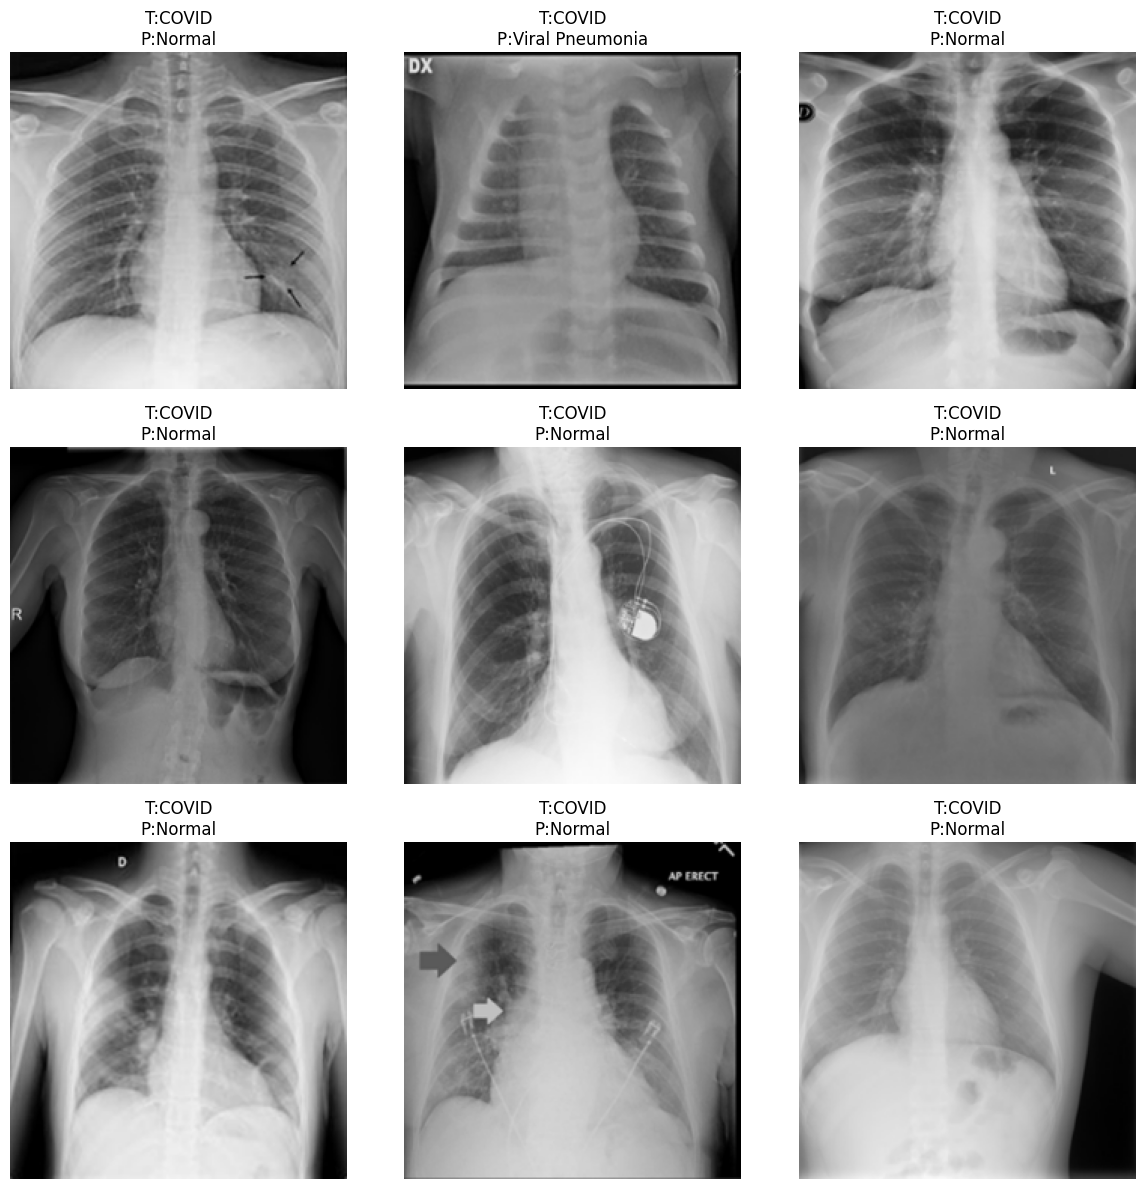

In [14]:
plt.figure(figsize=(12,12))

for i,index in enumerate(misclassified[:9]):

    image,label = list(test_ds.unbatch())[index]

    plt.subplot(3,3,i+1)

    plt.imshow(image.numpy().astype("uint8"))

    plt.title(
        f"T:{class_names[label]}\nP:{class_names[y_pred[index]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [15]:
loss, accuracy = model.evaluate(test_ds)

print("="*60)

print(f"Final Test Accuracy : {accuracy:.4f}")

print(f"Final Test Loss     : {loss:.4f}")

print("="*60)

48/48 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9460 - loss: 0.1499
Final Test Accuracy : 0.9460
Final Test Loss     : 0.1499
